In [1]:
import torch

print(f"Number of GPU: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    props = torch.cuda.get_device_properties(i)
    print(f"GPU {i}: {props.name}")
    print(f"  Memory: {props.total_memory / 1e9:.2f}GB")

Number of GPU: 1
GPU 0: NVIDIA GeForce MX450
  Memory: 2.15GB


In [2]:
import os

# Use only 1 GPU if available
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from chronos import BaseChronosPipeline, Chronos2Pipeline

# Load the Chronos-2 pipeline
# GPU recommended for faster inference, but CPU is also supported using device_map="cpu"
pipeline: Chronos2Pipeline = BaseChronosPipeline.from_pretrained("amazon/chronos-2", device_map="cuda")

/home/nguyentan/IOPO/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [30]:
# Load both CPU and Memory data
cpu_df = pd.read_csv("../../data/CPU Usage-compute1.csv")
memory_df = pd.read_csv("../../data/Memory Usage-compute1.csv")

print("CPU data shape:", cpu_df.shape)
print("Memory data shape:", memory_df.shape)

# Dictionary to store train/validation data for each metric
data_dict = {}

for metric_name, full_data in [('CPU', cpu_df), ('MEMORY', memory_df)]:
    # Filter by metric item_id
    metric_data = full_data[full_data['item_id'] == metric_name].copy()
    print(f"\n{metric_name} data: {len(metric_data)} rows")
    
    # Split into train (90%) and validation (10%)
    split_idx = int(len(metric_data) * 0.9)
    train_data = metric_data.iloc[:split_idx].copy()
    val_data = metric_data.iloc[split_idx:].copy()
    
    data_dict[metric_name] = {
        'full': metric_data,
        'train': train_data,
        'validation': val_data
    }
    
    print(f"  Train: {len(train_data)} rows")
    print(f"  Validation: {len(val_data)} rows")

print(f"\n\nCPU Train data (head):")
display(data_dict['CPU']['train'].head())
print(f"\nMemory Train data (head):")
display(data_dict['MEMORY']['train'].head())

CPU data shape: (2508, 4)
Memory data shape: (2509, 4)

CPU data: 2508 rows
  Train: 2257 rows
  Validation: 251 rows

MEMORY data: 2509 rows
  Train: 2258 rows
  Validation: 251 rows


CPU Train data (head):


,item_id,timestamp,target,running_vm
0,CPU,22/03/2026 07:33:15,85.551255,2
1,CPU,22/03/2026 07:33:30,53.348671,2
2,CPU,22/03/2026 07:33:45,81.466667,2
3,CPU,22/03/2026 07:34:00,64.430962,2
4,CPU,22/03/2026 07:34:15,30.366667,2



Memory Train data (head):


,item_id,timestamp,target,running_vm
0,MEMORY,22/03/2026 07:33:00,69.762820,2
1,MEMORY,22/03/2026 07:33:15,70.840795,2
2,MEMORY,22/03/2026 07:33:30,70.683341,2
3,MEMORY,22/03/2026 07:33:45,71.453508,2
4,MEMORY,22/03/2026 07:34:00,68.992169,2


In [32]:
# Make predictions for both CPU and MEMORY
predictions_dict = {}
train_data_dict = {}  # Store processed train data for debugging

for metric_name in ['CPU', 'MEMORY']:
    print(f"\n{'='*60}")
    print(f"Making predictions for {metric_name}")
    print(f"{'='*60}")
    
    train_data = data_dict[metric_name]['train'].copy()
    
    # Ensure timestamp is sorted and datetime
    train_data['timestamp'] = pd.to_datetime(train_data['timestamp'])
    train_data = train_data.sort_values('timestamp').reset_index(drop=True)
    
    # Remove duplicates if any
    train_data = train_data.drop_duplicates(subset=['timestamp']).reset_index(drop=True)
    
    # Store for debugging
    train_data_dict[metric_name] = train_data.copy()
    
    # Make predictions
    pred_df = pipeline.predict_df(train_data, prediction_length=251, 
                                  quantile_levels=[0.1, 0.5, 0.9])
    
    predictions_dict[metric_name] = pred_df
    
    print(f"\nOutput dataframe shape: {pred_df.shape}")
    print(f"Prediction stats:\n{pred_df['0.5'].describe()}")
    display(pred_df.head())


Making predictions for CPU


/tmp/ipykernel_59818/895893788.py:13: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  train_data['timestamp'] = pd.to_datetime(train_data['timestamp'])



Output dataframe shape: (251, 7)
Prediction stats:
count    251.000000
mean      26.194651
std        2.478626
min       22.378029
25%       24.480210
50%       26.345057
75%       27.877179
max       34.919388
Name: 0.5, dtype: float64


,item_id,timestamp,target_name,predictions,0.1,0.5,0.9
0,CPU,2026-03-22 16:57:30,target,34.919388,32.895687,34.919388,36.568054
1,CPU,2026-03-22 16:57:45,target,26.002409,24.486715,26.002409,27.577839
2,CPU,2026-03-22 16:58:00,target,29.318924,27.336971,29.318924,30.802225
3,CPU,2026-03-22 16:58:15,target,25.982361,24.047155,25.982361,27.770689
4,CPU,2026-03-22 16:58:30,target,34.530499,31.760237,34.530499,36.931854



Making predictions for MEMORY


/tmp/ipykernel_59818/895893788.py:13: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  train_data['timestamp'] = pd.to_datetime(train_data['timestamp'])



Output dataframe shape: (251, 7)
Prediction stats:
count    251.000000
mean      67.060936
std        0.010922
min       67.032379
25%       67.054157
50%       67.061302
75%       67.067623
max       67.085953
Name: 0.5, dtype: float64


,item_id,timestamp,target_name,predictions,0.1,0.5,0.9
0,MEMORY,2026-03-22 16:57:30,target,67.069229,66.811371,67.069229,67.324135
1,MEMORY,2026-03-22 16:57:45,target,67.081284,66.786072,67.081284,67.373344
2,MEMORY,2026-03-22 16:58:00,target,67.068146,66.755737,67.068146,67.379982
3,MEMORY,2026-03-22 16:58:15,target,67.077713,66.760735,67.077713,67.405144
4,MEMORY,2026-03-22 16:58:30,target,67.059135,66.739548,67.059135,67.386070


In [33]:
# Prepare data for comparison - CPU and MEMORY
comparison_dict = {}

for metric_name in ['CPU', 'MEMORY']:
    print(f"\n{'='*60}")
    print(f"Preparing comparison data for {metric_name}")
    print(f"{'='*60}")
    
    pred_df = predictions_dict[metric_name]
    val_data = data_dict[metric_name]['validation']
    
    # Extract the median predictions (0.5 quantile)
    pred_median = pred_df[['item_id', 'timestamp', '0.5']].copy()
    pred_median.columns = ['item_id', 'time', 'predicted_value']
    pred_median['time'] = pd.to_datetime(pred_median['time'])
    pred_median = pred_median.sort_values('time').reset_index(drop=True)
    
    # Prepare validation data - CRITICAL: Parse with dayfirst=True for DD/MM/YYYY format
    val_compare = val_data[['item_id', 'timestamp', 'target']].copy()
    val_compare['time'] = pd.to_datetime(val_compare['timestamp'], dayfirst=True)
    val_compare = val_compare[['item_id', 'time', 'target']].copy()
    val_compare.columns = ['item_id', 'time', 'actual_value']
    val_compare = val_compare.sort_values('time').reset_index(drop=True)
    
    # Merge predictions and validation by timestamp
    merged = pd.merge(pred_median, val_compare, on=['item_id', 'time'], how='inner')
    
    if len(merged) > 0:
        comparison_dict[metric_name] = {
            'predictions': merged[['item_id', 'time', 'predicted_value']],
            'actual': merged[['item_id', 'time', 'actual_value']],
            'pred_median': pred_median,
            'pred_df': pred_df
        }
        
        print(f"\nMerged shape: {len(merged)} (matched timestamps)")
        print(f"Sample timestamps after alignment:")
        display(merged[['time', 'predicted_value', 'actual_value']].head(5))
    else:
        print(f"WARNING: No matching timestamps found!")
        print(f"Predictions time range: {pred_median['time'].min()} to {pred_median['time'].max()}")
        print(f"Validation time range: {val_compare['time'].min()} to {val_compare['time'].max()}")


Preparing comparison data for CPU

Merged shape: 251 (matched timestamps)
Sample timestamps after alignment:


,time,predicted_value,actual_value
0,2026-03-22 16:57:30,34.919388,37.329155
1,2026-03-22 16:57:45,26.002409,26.376483
2,2026-03-22 16:58:00,29.318924,28.923857
3,2026-03-22 16:58:15,25.982361,27.971469
4,2026-03-22 16:58:30,34.530499,36.400000



Preparing comparison data for MEMORY

Merged shape: 251 (matched timestamps)
Sample timestamps after alignment:


,time,predicted_value,actual_value
0,2026-03-22 16:57:30,67.069229,66.839769
1,2026-03-22 16:57:45,67.081284,66.899943
2,2026-03-22 16:58:00,67.068146,66.754266
3,2026-03-22 16:58:15,67.077713,66.894942
4,2026-03-22 16:58:30,67.059135,66.648921


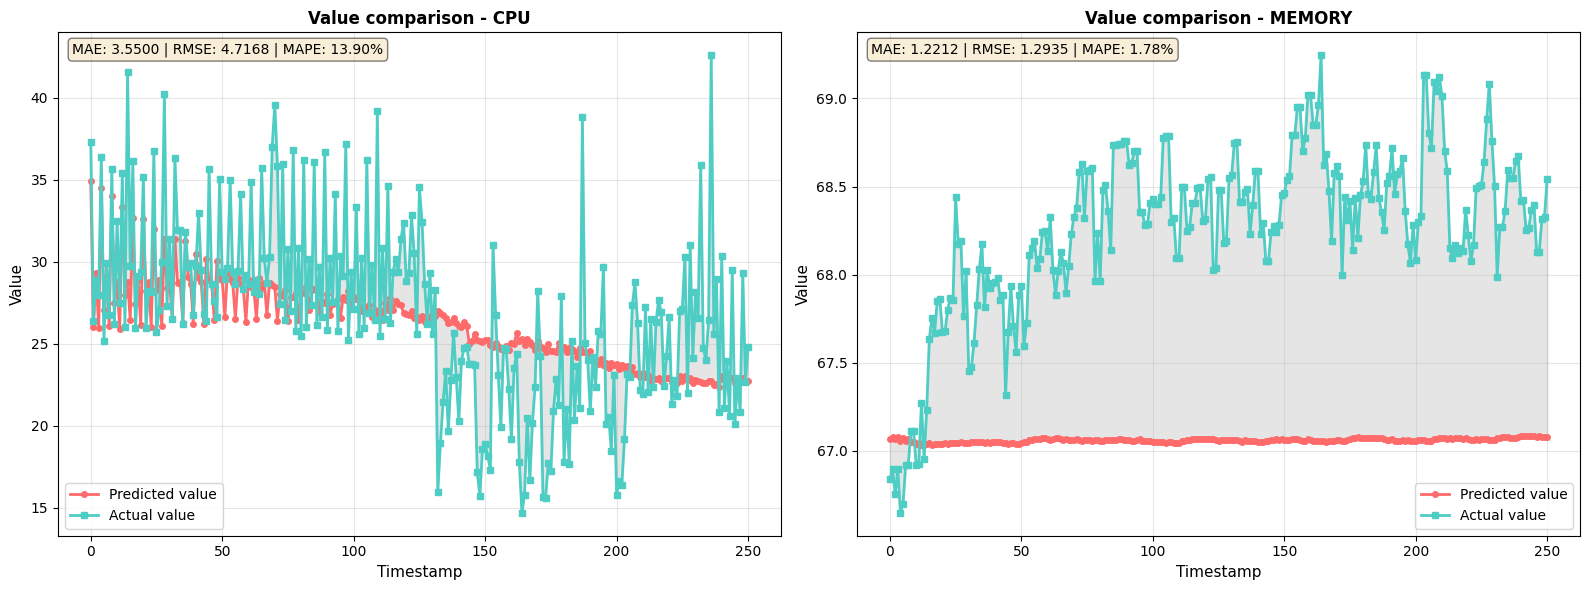


Evaluation Metrics for CPU and MEMORY:

CPU:
  Mean Absolute Error (MAE):        3.5500
  Root Mean Square Error (RMSE):   4.7168
  Mean Absolute Percentage Error (MAPE): 13.90%

MEMORY:
  Mean Absolute Error (MAE):        1.2212
  Root Mean Square Error (RMSE):   1.2935
  Mean Absolute Percentage Error (MAPE): 1.78%



In [34]:
# Plot: Predicted vs Actual values for CPU and MEMORY
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
metrics_summary = {}

for idx, metric_name in enumerate(['CPU', 'MEMORY']):
    if metric_name in comparison_dict:
        pred_data = comparison_dict[metric_name]['predictions']
        actual_data = comparison_dict[metric_name]['actual']
        
        if len(pred_data) > 0 and len(actual_data) > 0:
            n_compare = min(len(pred_data), len(actual_data))
            
            x_axis = np.arange(n_compare)
            predicted_values = pred_data['predicted_value'].values[:n_compare]
            actual_values = actual_data['actual_value'].values[:n_compare]
            
            # Plot both lines
            axes[idx].plot(x_axis, predicted_values, label='Predicted value', 
                   color='#FF6B6B', linewidth=2, marker='o', markersize=4)
            axes[idx].plot(x_axis, actual_values, label='Actual value', 
                   color='#4ECDC4', linewidth=2, marker='s', markersize=4)
            
            # Add shaded area
            axes[idx].fill_between(x_axis, predicted_values, actual_values, 
                        alpha=0.2, color='gray')
            
            # Formatting
            axes[idx].set_xlabel('Timestamp', fontsize=11)
            axes[idx].set_ylabel('Value', fontsize=11)
            axes[idx].set_title(f'Value comparison - {metric_name}', 
                        fontsize=12, fontweight='bold')
            axes[idx].legend(fontsize=10, loc='best')
            axes[idx].grid(True, alpha=0.3)
            
            # Calculate error metrics
            mae = np.mean(np.abs(predicted_values - actual_values))
            rmse = np.sqrt(np.mean((predicted_values - actual_values) ** 2))
            mape = np.mean(np.abs((actual_values - predicted_values) / (actual_values + 1e-10))) * 100
            
            metrics_summary[metric_name] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}
            
            # Add metrics text
            metrics_text = f"MAE: {mae:.4f} | RMSE: {rmse:.4f} | MAPE: {mape:.2f}%"
            axes[idx].text(0.02, 0.98, metrics_text, transform=axes[idx].transAxes,
                   fontsize=10, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Print detailed metrics
print(f"\n{'='*70}")
print(f"Evaluation Metrics for CPU and MEMORY:")
print(f"{'='*70}")

for metric_name, metrics in metrics_summary.items():
    print(f"\n{metric_name}:")
    print(f"  Mean Absolute Error (MAE):        {metrics['MAE']:.4f}")
    print(f"  Root Mean Square Error (RMSE):   {metrics['RMSE']:.4f}")
    print(f"  Mean Absolute Percentage Error (MAPE): {metrics['MAPE']:.2f}%")

print(f"\n{'='*70}")

/tmp/ipykernel_59818/42121802.py:30: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  train_context['timestamp'] = pd.to_datetime(train_context['timestamp'])
/tmp/ipykernel_59818/42121802.py:30: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  train_context['timestamp'] = pd.to_datetime(train_context['timestamp'])


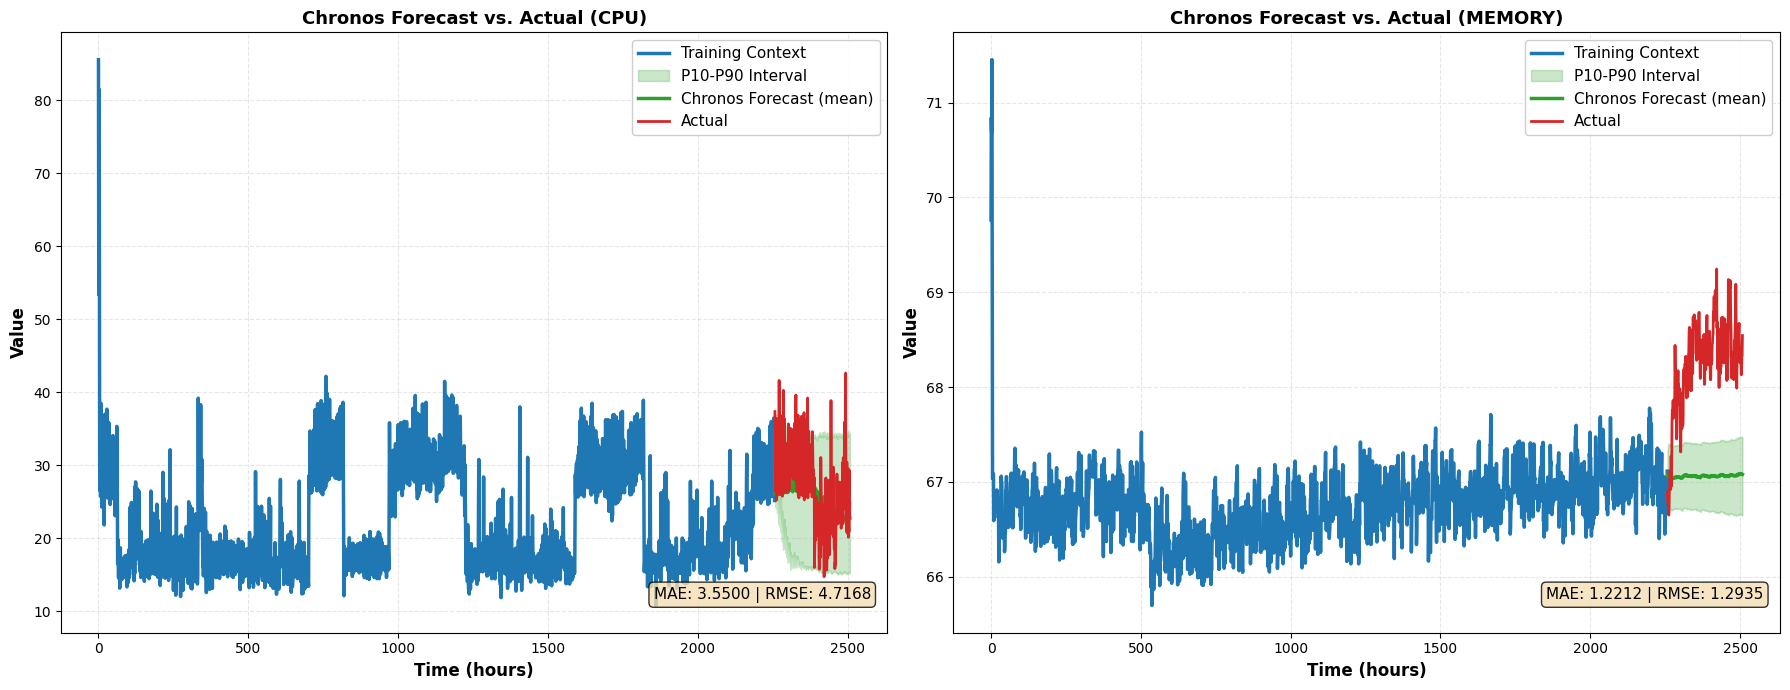

In [35]:
# Plot: Chronos-style forecast with confidence interval for both metrics
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for idx, metric_name in enumerate(['CPU', 'MEMORY']):
    if metric_name in comparison_dict:
        pred_df = comparison_dict[metric_name]['pred_df']
        pred_median = comparison_dict[metric_name]['pred_median']
        actual_data = comparison_dict[metric_name]['actual']
        train_data = data_dict[metric_name]['train']
        
        ax = axes[idx]
        
        # Get confidence intervals (P10-P90)
        conf_low = pred_df[['item_id', 'timestamp', '0.1']].copy()
        conf_low.columns = ['item_id', 'time', 'p10']
        conf_low['time'] = pd.to_datetime(conf_low['time'])
        conf_low = conf_low.sort_values('time').reset_index(drop=True)
        
        conf_high = pred_df[['item_id', 'timestamp', '0.9']].copy()
        conf_high.columns = ['item_id', 'time', 'p90']
        conf_high['time'] = pd.to_datetime(conf_high['time'])
        conf_high = conf_high.sort_values('time').reset_index(drop=True)
        
        # Merge confidence intervals with predictions
        conf_data = pd.merge(pred_median, conf_low, on=['item_id', 'time'], how='inner')
        conf_data = pd.merge(conf_data, conf_high, on=['item_id', 'time'], how='inner')
        
        # Prepare training context (last values from train_data)
        train_context = train_data[['item_id', 'timestamp', 'target']].copy()
        train_context['timestamp'] = pd.to_datetime(train_context['timestamp'])
        train_context = train_context.sort_values('timestamp').reset_index(drop=True)
        
        # Calculate position offsets
        x_train = np.arange(len(train_context))
        x_offset = len(train_context)
        x_forecast = np.arange(len(conf_data)) + x_offset
        
        # Plot training context (historical data)
        if len(train_context) > 0:
            ax.plot(x_train, train_context['target'].values, 
                   label='Training Context', color='#1f77b4', linewidth=2.5, zorder=2)
        
        # Plot confidence interval (P10-P90)
        if len(conf_data) > 0:
            ax.fill_between(x_forecast, conf_data['p10'].values, conf_data['p90'].values,
                           alpha=0.25, color='#2ca02c', label='P10-P90 Interval', zorder=1)
            
            # Plot forecast mean
            ax.plot(x_forecast, conf_data['predicted_value'].values, 
                   label='Chronos Forecast (mean)', color='#2ca02c', linewidth=2.5, zorder=3)
        
        # Plot actual validation values
        if len(actual_data) > 0:
            x_actual = np.arange(len(actual_data)) + x_offset
            ax.plot(x_actual, actual_data['actual_value'].values, 
                   label='Actual', color='#d62728', linewidth=2, zorder=3)
        
        # Formatting
        ax.set_xlabel('Time (hours)', fontsize=12, fontweight='bold')
        ax.set_ylabel('Value', fontsize=12, fontweight='bold')
        ax.set_title(f'Chronos Forecast vs. Actual ({metric_name})', 
                    fontsize=13, fontweight='bold')
        ax.legend(fontsize=11, loc='best', framealpha=0.95)
        ax.grid(True, alpha=0.3, linestyle='--')
        
        # Calculate metrics for the forecast period
        if len(conf_data) > 0 and len(actual_data) > 0:
            n_metrics = min(len(conf_data), len(actual_data))
            pred_vals = conf_data['predicted_value'].values[:n_metrics]
            actual_vals = actual_data['actual_value'].values[:n_metrics]
            
            mae = np.mean(np.abs(pred_vals - actual_vals))
            rmse = np.sqrt(np.mean((pred_vals - actual_vals) ** 2))
            
            # Add metrics box
            metrics_text = f"MAE: {mae:.4f} | RMSE: {rmse:.4f}"
            ax.text(0.98, 0.05, metrics_text, transform=ax.transAxes,
                   fontsize=11, verticalalignment='bottom', horizontalalignment='right',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()